In [1]:
import numpy as np
from rsm3d.data_io import RSMDataloader_CMS
from rsm3d.rsm3d import RSMBuilder  # <-- 4-circle xrayutilities builder
from rsm3d.data_viz import RSMNapariViewer
setup_file = './cms_setup.yaml'
tiff_dir  = '/nsls2/users/xyang4/data/data_cs/cms_rsm3d/2022_3/stitched3/'
crop_region = ((624, 1624), (232, 1232))  # Example crop region (y, x)
selected_scans = list(range(796715, 796715+721))
loader = RSMDataloader_CMS(
    setup_file,
    tiff_dir,
    crop_window=crop_region,
    selected_scans=selected_scans,
    angle_overrides= {"th": np.arange(len(selected_scans), dtype=float) * 0.5}
)

In [2]:
setup, frames_df = loader.load()

In [3]:
print(frames_df.th)

0        0.0
1        0.5
2        1.0
3        1.5
4        2.0
       ...  
356    178.0
357    178.5
358    179.0
359    179.5
360    180.0
Name: th, Length: 361, dtype: float64


In [2]:
builder = RSMBuilder(loader,
                    #  sample_axes = ('z-', 'y+', 'x+'),
                    #  detector_axes = ('z-',),
                     )
print("Building RSM...")
Q_samp, intensity = builder.compute_full()

Initializing QConversion area...
Initialized QConversion area with:
  Sample Axis: ('z-', 'y-', 'x+')
  Detector Axis: ('z+',)
  Beam Direction: (0, 1, 0)
  Wavelength: 0.918400 Å
  Distance: 3.030000 m
  Pixel Width: 0.000172 m
Building RSM...


In [3]:
grid, (xax, yax, zax) = builder.regrid_xu(
   space="q",
   grid_shape=(200, None, None),
   fuzzy=True,
   normalize="mean",
   stream=True
)

In [5]:
print(grid.shape, xax.shape, yax.shape, zax.shape)
print(xax.min(), xax.max())
import tifffile
tifffile.imwrite('/nsls2/users/xyang4/data/data_cs/cms_rsm3d/rsm3d_data/cms_rsm3d_721_qz_stack_200.tiff', grid.astype(np.float32))

(200, 200, 200) (200,) (200,) (200,)
-0.19412003457546234 0.19412003457546234


In [4]:
viz = RSMNapariViewer(
    grid, (xax, yax, zax),
    space="q",               # or "q"
    name="RSM",
    log_view=True,
    
    contrast_percentiles=(1, 99.8),
    cmap="inferno",
    rendering="attenuated_mip",  # or "mip", "translucent"
)
# launch returns the raw napari.Viewer
viewer = viz.launch()

(1000, 1000)


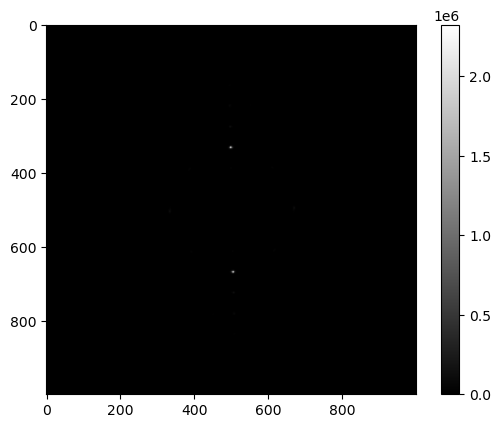

In [4]:
import matplotlib.pyplot as plt
print(frames_df.intensity[1].shape)
plt.imshow(frames_df.intensity[1], cmap='gray')
plt.colorbar()
plt.show()

In [12]:
import numpy as np

# Assign omega values starting at 0 with 0.5° increments
omega = np.arange(len(frames_df.intensity), dtype=float) * 0.5
print(omega)
print(frames_df.loc[:, "th"])
frames_df = frames_df.copy()
frames_df.loc[:, "th"] = omega

frames_df.head()

[0.  0.5 1.  1.5 2.  2.5 3.  3.5 4.  4.5]
0    0.0
1    0.0
2    0.0
3    0.0
4    0.0
5    0.0
6    0.0
7    0.0
8    0.0
9    0.0
Name: th, dtype: float64


,scan_number,intensity,tth,th,chi,phi
0,796715,"[[0, 32, 30, 0, 0, 201, 28, 0, 0, 0, 0, 35, 46...",0.0,0.0,0.0,0.0
1,796716,"[[0, 32, 30, 0, 0, 201, 28, 0, 0, 0, 0, 35, 46...",0.0,0.5,0.0,0.0
2,796717,"[[0, 32, 30, 0, 0, 201, 28, 0, 0, 0, 0, 35, 46...",0.0,1.0,0.0,0.0
3,796718,"[[0, 32, 30, 0, 0, 201, 28, 0, 0, 0, 0, 35, 46...",0.0,1.5,0.0,0.0
4,796719,"[[0, 32, 30, 0, 0, 201, 28, 0, 0, 0, 0, 35, 46...",0.0,2.0,0.0,0.0


In [16]:
import numpy as np
import xrayutilities as xu

# Instrument geometry parameters
wavelength_A = 0.9184          # Angstroms
pixel_size_m = 0.172e-3        # meters
sample_detector_distance_m = 3.03  # meters
beam_center = (733, 1679 - 553)    # (row, col) in pixels

# Prepare xrayutilities conversion (sample axes defined outer→inner)
sample_axes = ['z-', 'y-', 'x+']
detector_axes = ['z+']
beam_direction = (0, 1, 0)  # +Y
ny, nx = frames_df.loc[0, 'intensity'].shape
qconv = xu.experiment.QConversion(sample_axes, detector_axes, beam_direction, wl=wavelength_A)
qconv.init_area(
    'z-', 'x+',
    cch1=beam_center[0],
    cch2=beam_center[1],
    Nch1=ny,
    Nch2=nx,
    distance=sample_detector_distance_m,
    pwidth1=pixel_size_m,
    pwidth2=pixel_size_m,
    detrot=0.0,
    tiltazimuth=0.0,
    tilt=0.0,
)


def compute_q_space(idx, frame_row):
    """Return q-components and magnitude grids for a single frame."""
    omega_deg = float(frame_row.th)
    qx, qy, qz = qconv.area(omega_deg, 0.0, 0.0, 0.0, deg=True)
    q_mag = np.sqrt(qx**2 + qy**2 + qz**2)
    return {
        "frame_index": idx,
        "omega_deg": omega_deg,
        "qx": qx,
        "qy": qy,
        "qz": qz,
        "q_mag": q_mag,
        "intensity": frame_row.intensity,
    }

# Convert every frame in the stack to Q-space coordinates
q_space_frames = [
    compute_q_space(idx, row)
    for idx, row in enumerate(frames_df.itertuples(index=False))
]

example = q_space_frames[0]
print(f"qx shape: {example['qx'].shape}")
print(f"qy shape: {example['qy'].shape}")
print(f"qz shape: {example['qz'].shape}")
print(
    f"Frame {example['frame_index']}: q-grid shape = {example['qx'].shape}, "
    f"intensity shape = {example['intensity'].shape}"
)


qx shape: (1000, 1000)
qy shape: (1000, 1000)
qz shape: (1000, 1000)
Frame 0: q-grid shape = (1000, 1000), intensity shape = (1000, 1000)


In [9]:
def _axis_spacing(axis):
    if axis is None or getattr(axis, "size", 0) < 2:
        return 1.0
    return float(np.abs(axis[1] - axis[0]))

dx = _axis_spacing(xax)
dy = _axis_spacing(yax)
dz = _axis_spacing(zax)

fft_grid = np.fft.fftn(grid, axes=(0, 1, 2), norm="ortho")
fft_grid = np.fft.fftshift(fft_grid, axes=(0, 1, 2))
fft_magnitude = np.abs(fft_grid)

kx = np.fft.fftshift(np.fft.fftfreq(grid.shape[0], d=dx))
ky = np.fft.fftshift(np.fft.fftfreq(grid.shape[1], d=dy))
kz = np.fft.fftshift(np.fft.fftfreq(grid.shape[2], d=dz))

print("FFT grid shape:", fft_grid.shape)
print("kx span:", kx.min(), kx.max())

FFT grid shape: (160, 160, 160)
kx span: -204.7702087367368 202.2105811275276
